# Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive

my_drive = '/content/drive'
drive.mount(my_drive)
dir_name = '/content/drive/MyDrive/Colab Notebooks/'
df = pd.read_csv(dir_name + 'academic Stress level - maintainance 1.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [ ]:
df.head()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            140 non-null    object
 1   Your Academic Stage                                                  140 non-null    object
 2   Peer pressure                                                        140 non-null    int64 
 3   Academic pressure from your home                                     140 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           140 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  140 non-null    object
 7   What would you rat

In [ ]:
print(df.isnull().sum())

Timestamp                                                              0
Your Academic Stage                                                    0
Peer pressure                                                          0
Academic pressure from your home                                       0
Study Environment                                                      1
What coping strategy you use as a student?                             0
Do you have any bad habits like smoking, drinking on a daily basis?    0
What would you rate the academic  competition in your student life     0
Rate your academic stress index                                        0
dtype: int64


In [ ]:
df.describe(include=['O'])

,Timestamp,Your Academic Stage,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?"
count,140,140,139,140,140
unique,140,3,3,3,3
top,24/07/2025 22:05:39,undergraduate,Peaceful,Analyze the situation and handle it with intel...,No
freq,1,100,69,87,123


In [ ]:
df['Study Environment'].fillna(df['Study Environment'].mode()[0], inplace = True)

/tmp/ipython-input-2594091144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Study Environment'].fillna(df['Study Environment'].mode()[0], inplace = True)


In [ ]:
print(df.isnull().sum())

Timestamp                                                              0
Your Academic Stage                                                    0
Peer pressure                                                          0
Academic pressure from your home                                       0
Study Environment                                                      0
What coping strategy you use as a student?                             0
Do you have any bad habits like smoking, drinking on a daily basis?    0
What would you rate the academic  competition in your student life     0
Rate your academic stress index                                        0
dtype: int64


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns #checks categorical columns
categorical_cols

Index(['Timestamp', 'Your Academic Stage', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?'],
      dtype='object')

In [ ]:
'''
for x in categorical_cols:
  print(x)
  print(df[x].unique()) #this code works just remove comment
  print("\n")
  '''

'\nfor x in categorical_cols:\n  print(x)\n  print(df[x].unique()) #this code works just remove comment\n  print("\n")\n  '

In [ ]:
df['Your Academic Stage'].unique()

array(['undergraduate', 'high school', 'post-graduate'], dtype=object)

In [ ]:
df['Study Environment'].unique()

array(['Noisy', 'Peaceful', 'disrupted'], dtype=object)

In [ ]:
df['What coping strategy you use as a student?'].unique()

array(['Analyze the situation and handle it with intellect',
       'Social support (friends, family)',
       'Emotional breakdown (crying a lot)'], dtype=object)

In [ ]:
df['Do you have any bad habits like smoking, drinking on a daily basis?'].unique()

array(['No', 'prefer not to say', 'Yes'], dtype=object)

In [ ]:
df['Study Environment'] = df['Study Environment'].str.capitalize()
df['Study Environment'].unique()

array(['Noisy', 'Peaceful', 'Disrupted'], dtype=object)

In [ ]:
df.rename(columns={
    'Study Environment': 'Study_environment',
    'Your Academic Stage': 'Academic_stage',
    'What coping strategy you use as a student?': 'Coping_strategy',
    'Do you have any bad habits like smoking, drinking on a daily basis?': 'Bad_habits',
    'What would you rate the academic  competition in your student life': 'Competition_rating',
    'Rate your academic stress index ' : 'Stress_index',
    'Peer pressure' : 'Peer_pressure',
    'Academic pressure from your home' : 'Academic_pressure'
}, inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Timestamp           140 non-null    object
 1   Academic_stage      140 non-null    object
 2   Peer_pressure       140 non-null    int64 
 3   Academic_pressure   140 non-null    int64 
 4   Study_environment   140 non-null    object
 5   Coping_strategy     140 non-null    object
 6   Bad_habits          140 non-null    object
 7   Competition_rating  140 non-null    int64 
 8   Stress_index        140 non-null    int64 
dtypes: int64(4), object(5)
memory usage: 10.0+ KB


In [ ]:
df['Bad_habits'].value_counts()

,count
Bad_habits,
No,123
Yes,10
prefer not to say,7


# Start of Feature Engineering

In [ ]:
df['Total_pressure'] = df['Peer_pressure'] + df['Academic_pressure']
df

,Timestamp,Academic_stage,Peer_pressure,Academic_pressure,Study_environment,Coping_strategy,Bad_habits,Competition_rating,Stress_index,Total_pressure
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5,9
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3,7
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4,2
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3,5
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5,6
...,...,...,...,...,...,...,...,...,...,...
135,17/08/2025 13:02:04,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,3,4,5
136,18/08/2025 14:36:00,undergraduate,4,2,Disrupted,Analyze the situation and handle it with intel...,No,3,3,6
137,18/08/2025 17:13:52,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,2,4,6
138,18/08/2025 19:08:52,undergraduate,4,5,Disrupted,"Social support (friends, family)",No,5,5,9


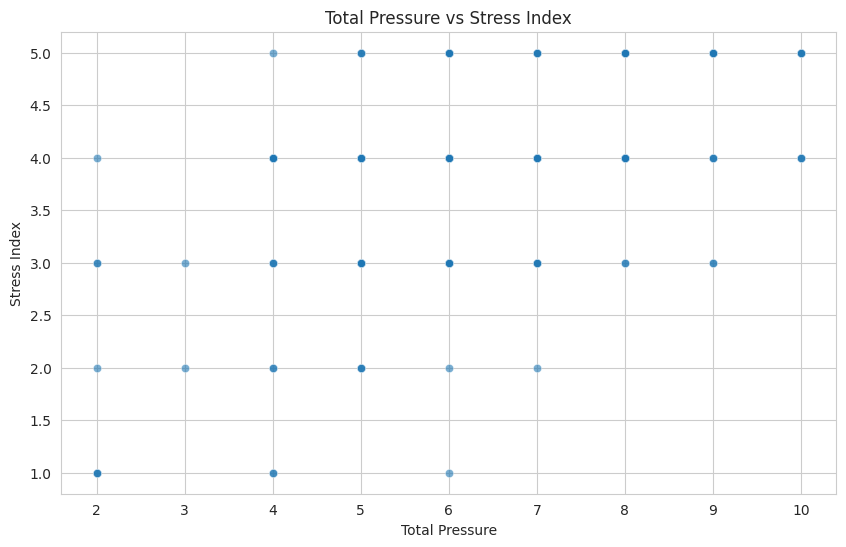

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Total_pressure'], y=df['Stress_index'], alpha=0.6)
plt.title('Total Pressure vs Stress Index')
plt.xlabel('Total Pressure')
plt.ylabel('Stress Index')
plt.show()

In [ ]:
env_stress = df.groupby('Study_environment')['Stress_index'].mean().sort_values()
env_stress

,Stress_index
Study_environment,
Peaceful,3.500000
Noisy,3.843750
Disrupted,4.026316


In [ ]:
df['Env_disrupted'] = (df['Study_environment'] == 'Disrupted').astype(int)
df['Env_disrupted']

,Env_disrupted
0,0
1,0
2,0
3,0
4,0
...,...
135,0
136,1
137,0
138,1


In [ ]:
df.groupby('Env_disrupted')['Stress_index'].mean().sort_values()

,Stress_index
Env_disrupted,
0,3.607843
1,4.026316


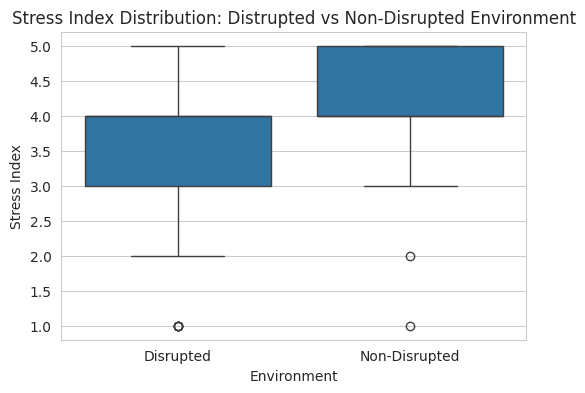

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Env_disrupted'], y=df['Stress_index'])
plt.title('Stress Index Distribution: Distrupted vs Non-Disrupted Environment')
plt.xticks([0, 1], ['Disrupted', 'Non-Disrupted'])
plt.xlabel('Environment')
plt.ylabel('Stress Index')
plt.show()

In [ ]:
df['Coping_strategy'].unique()

array(['Analyze the situation and handle it with intellect',
       'Social support (friends, family)',
       'Emotional breakdown (crying a lot)'], dtype=object)

In [ ]:
strategy_mapping = {
    'Analyze the situation and handle it with intellect':'Problem-Focused',
    'Social support (friends, family)': 'Social-Support',
    'Emotional breakdown (crying a lot)' : 'Emotional-Focused',
}

df["Coping_strategy_type"] = df['Coping_strategy'].map(strategy_mapping)

In [ ]:
df["Coping_strategy_type"].value_counts()

,count
Coping_strategy_type,
Problem-Focused,87
Emotional-Focused,32
Social-Support,21


/tmp/ipython-input-4277325570.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df['Coping_strategy_type'], y=df['Stress_index'], estimator=np.mean, ci=None)


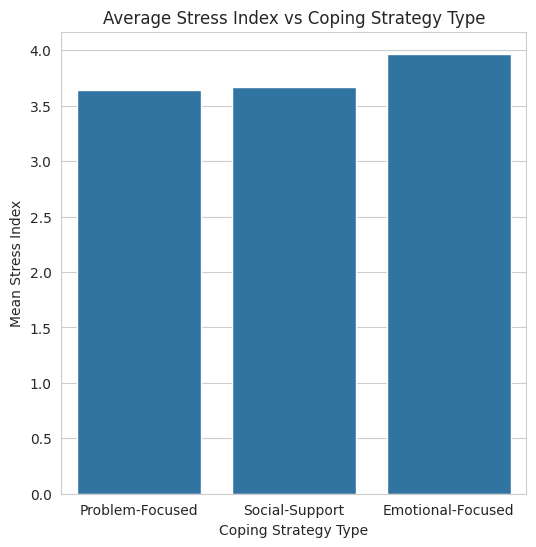

In [ ]:
plt.figure(figsize=(6,6))
sns.barplot(x=df['Coping_strategy_type'], y=df['Stress_index'], estimator=np.mean, ci=None)
plt.title('Average Stress Index vs Coping Strategy Type')
plt.xlabel('Coping Strategy Type')
plt.ylabel('Mean Stress Index')
plt.show()

# Train-set split

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.preprocessing import StandardScaler

In [ ]:
df.head(5)

,Timestamp,Academic_stage,Peer_pressure,Academic_pressure,Study_environment,Coping_strategy,Bad_habits,Competition_rating,Stress_index,Total_pressure,Env_disrupted,Coping_strategy_type
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5,9,0,Problem-Focused
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3,7,0,Problem-Focused
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4,2,0,Social-Support
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3,5,0,Problem-Focused
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5,6,0,Problem-Focused


In [ ]:
y = df['Stress_index'] # Target (Predicted Category)

In [ ]:
df.columns

Index(['Timestamp', 'Academic_stage', 'Peer_pressure', 'Academic_pressure',
       'Study_environment', 'Coping_strategy', 'Bad_habits',
       'Competition_rating', 'Stress_index', 'Total_pressure', 'Env_disrupted',
       'Coping_strategy_type'],
      dtype='object')

In [ ]:
X = df.drop(["Timestamp", "Stress_index", "Peer_pressure", 'Academic_pressure','Study_environment', 'Coping_strategy'], axis = 1)

In [ ]:
X.head()

,Academic_stage,Bad_habits,Competition_rating,Total_pressure,Env_disrupted,Coping_strategy_type
0,undergraduate,No,3,9,0,Problem-Focused
1,undergraduate,No,3,7,0,Problem-Focused
2,undergraduate,No,2,2,0,Social-Support
3,undergraduate,No,4,5,0,Problem-Focused
4,undergraduate,No,4,6,0,Problem-Focused


In [ ]:
X.shape

(140, 6)

In [ ]:
# split the data into training (80%) and testing (20%) sets, with a fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(112, 6)

In [ ]:
X_test.shape

(28, 6)

In [ ]:
y_train.shape

(112,)

In [ ]:
y_test.shape

(28,)

In [ ]:
# Let's list the data types of our features in the TRAINING set
print(X_train.dtypes)

# Separate column names by type
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Academic_stage          object
Bad_habits              object
Competition_rating       int64
Total_pressure           int64
Env_disrupted            int64
Coping_strategy_type    object
dtype: object

Numerical columns: ['Competition_rating', 'Total_pressure', 'Env_disrupted']
Categorical columns: ['Academic_stage', 'Bad_habits', 'Coping_strategy_type']


# Feature Encoding: Talking the Model's Language

In [ ]:
# Initialize the OneHotEncoder. handle_unknown='ignore' is VITAL for the test set.
# If the test set has a category not seen in training, it will ignore it instead of throwing an error.
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 5.1 FIT: Learn the categories from the TRAINING data
encoder.fit(X_train[categorical_cols])

# 5.2 TRANSFORM: Apply the encoding to both the training and test data
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Get the names of the new encoded columns (e.g., Academic_Stage_undergraduate, etc.)
encoded_categories = encoder.get_feature_names_out(categorical_cols)

# Convert the encoded arrays back to DataFrames
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_categories, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_categories, index=X_test.index)

# Now, let's combine the encoded features with the numerical features
# First, drop the original categorical columns from X_train and X_test
X_train = X_train.drop(categorical_cols, axis=1)
X_test = X_test.drop(categorical_cols, axis=1)

# Then, concatenate the numerical features with the encoded ones
X_train_final = pd.concat([X_train, X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test, X_test_encoded_df], axis=1)

print("Final Training set shape:", X_train_final.shape)
X_train_final.head()

Final Training set shape: (112, 12)


,Competition_rating,Total_pressure,Env_disrupted,Academic_stage_high school,Academic_stage_post-graduate,Academic_stage_undergraduate,Bad_habits_No,Bad_habits_Yes,Bad_habits_prefer not to say,Coping_strategy_type_Emotional-Focused,Coping_strategy_type_Problem-Focused,Coping_strategy_type_Social-Support
16,5,6,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
18,4,6,0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
10,3,5,1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
111,3,2,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
101,5,6,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Feature Scaling: Leveling the Playing Field

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# 6.1 FIT: Learn the mean and standard deviation from the TRAINING data
scaler.fit(X_train_final[numerical_cols])

# 6.2 TRANSFORM: Apply the scaling to both the training and test data
X_train_final[numerical_cols] = scaler.transform(X_train_final[numerical_cols])
X_test_final[numerical_cols] = scaler.transform(X_test_final[numerical_cols])

# Check the final processed training set
print("Scaled Training set stats:")
print(pd.DataFrame(X_train_final[numerical_cols]).describe().round(2))

Scaled Training set stats:
       Competition_rating  Total_pressure  Env_disrupted
count              112.00          112.00         112.00
mean                 0.00           -0.00           0.00
std                  1.00            1.00           1.00
min                 -2.32           -2.12          -0.60
25%                 -0.46           -0.59          -0.60
50%                  0.46           -0.07          -0.60
75%                  0.46            0.44           1.65
max                  1.39            1.98           1.65


# Model Training

In [ ]:
from sklearn.ensemble import RandomForestRegressor # 1. import the model

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42) # 2. Initializing the model

In [ ]:
rf.fit(X_train_final, y_train) # 3. Training using .fit()

RandomForestRegressor(random_state=42)

In [ ]:
y_train_pred = rf.predict(X_train_final) # 4a. Predict on the Training data

In [ ]:
y_test_pred = rf.predict(X_test_final) # 4a. Predict on unseen data

In [ ]:
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred}) # create a DataFrame to compare actual vs. predicted values and print it
print(df)

     Actual  Predicted
108       4   3.740000
67        4   4.286667
31        4   3.619583
119       5   4.450500
42        5   3.953500
12        2   2.418833
81        5   4.092000
69        4   3.125000
104       5   4.406000
109       3   3.413333
113       3   3.834500
56        4   3.840000
66        5   3.986000
19        3   4.520000
132       2   2.761667
78        4   3.745810
11        3   4.492048
27        4   3.804167
127       5   4.250000
110       3   3.552714
36        3   4.762000
118       4   3.455833
60        2   2.687000
4         5   3.400349
131       4   3.981000
26        5   4.250000
138       5   4.570000
96        4   3.470167


# Model Evaluation

In [ ]:
# For regression algorithms
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# calculate the metrics
print("R² Score:", r2_score(y_test, y_test_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_test_pred))
print("Root Mean Squared Error(RMSE):", np.sqrt(mean_squared_error(y_test, y_test_pred)))

R² Score: 0.277368340656571
Mean Absolute Error (MAE): 0.6996018990929704
Root Mean Squared Error(RMSE): 0.829775794596278


In [ ]:
from sklearn.linear_model import LinearRegression
models = {'lr' : LinearRegression(),
          'rf' : RandomForestRegressor(random_state=42)}

for name, model in models.items():
  print('Model is', name)
  model.fit(X_train_final, y_train)
  y_pred = model.predict(X_test_final)
  # calculate the metrics
  print("R² Score:", r2_score(y_test, y_pred))
  print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
  print("Root Mean Squared Error(RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))

Model is lr
R² Score: 0.40538692289543343
Mean Absolute Error (MAE): 0.6553015077423133
Root Mean Squared Error(RMSE): 0.7526958086461344
Model is rf
R² Score: 0.277368340656571
Mean Absolute Error (MAE): 0.6996018990929704
Root Mean Squared Error(RMSE): 0.829775794596278
